# Urdu HMM Part-of-Speech Tagger
## Hidden Markov Model with Viterbi Decoding

**Author:** Mian Ameer Muhammad (FA23-BAI-021) 

**Course:** Machine Learning / Classical NLP  
**Dataset:** CLE-style Urdu POS Corpus  

---
This notebook implements a **Hidden Markov Model (HMM)** for Part-of-Speech (POS) tagging on Urdu text.  
We use **Maximum Likelihood Estimation** with **Laplace smoothing** for training and the **Viterbi** dynamic programming algorithm for decoding.

### Contents
1. [Setup & Imports](#1-setup)  
2. [Dataset Loading & Exploration](#2-dataset)  
3. [HMM Training](#3-training)  
4. [Viterbi Decoding — Worked Example](#4-viterbi)  
5. [Evaluation](#5-evaluation)  
6. [Confusion Matrix](#6-confusion)  
7. [Error Analysis](#7-errors)  
8. [Tag Sequence Visualization](#8-visualization)  


## 1. Setup & Imports <a id='1-setup'></a>

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter

from src import DataLoader, HMMTagger, evaluate, print_report, error_analysis

# Matplotlib settings for Urdu-compatible display
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
print("All imports successful!")


All imports successful!


## 2. Dataset Loading & Exploration <a id='2-dataset'></a>

We use a CLE-style Urdu POS corpus with tab-separated `word\tTAG` format.
The dataset contains **400 sentences** covering common Urdu sentence structures.


In [2]:
loader = DataLoader(format='cle')

train_path = os.path.join(os.getcwd(), '..', 'data', 'train.txt')
test_path  = os.path.join(os.getcwd(), '..', 'data', 'test.txt')

train_sents = loader.load(train_path)
test_sents  = loader.load(test_path)

train_stats = loader.corpus_stats(train_sents)
test_stats  = loader.corpus_stats(test_sents)

print("Training set:")
for k, v in train_stats.items():
    if k != 'tag_freq':
        print(f"  {k}: {v}")

print("\nTest set:")
for k, v in test_stats.items():
    if k != 'tag_freq':
        print(f"  {k}: {v}")


Training set:
  num_sentences: 320
  num_tokens: 1813
  vocab_size: 199
  num_tags: 14

Test set:
  num_sentences: 80
  num_tokens: 469
  vocab_size: 146
  num_tags: 14


In [3]:
# Show 5 sample sentences
print("Sample annotated sentences (word/TAG):\n")
for i, sent in enumerate(train_sents[:5]):
    display = '  '.join(f'{w}/{t}' for w, t in sent)
    print(f"[{i+1}] {display}")


Sample annotated sentences (word/TAG):

[1] میں/PRP  کی/IN  آسمان/NN  ہمیشہ/RB  دیا/VBD  ،/PUNC
[2] دونوں/DT  پانی/NN  ساتھ/RB  غریب/JJ  ہے/VBZ  ۔/PUNC
[3] کچھ/DT  پھول/NN  مشکل/JJ  ہے/VBZ  :/PUNC
[4] اسے/PRP  کا/IN  دریا/NN  مت/NEG  کھایا/VBD  ،/PUNC
[5] آنکھ/NN  خوبصورت/JJ  ہے/VBZ  ،/PUNC


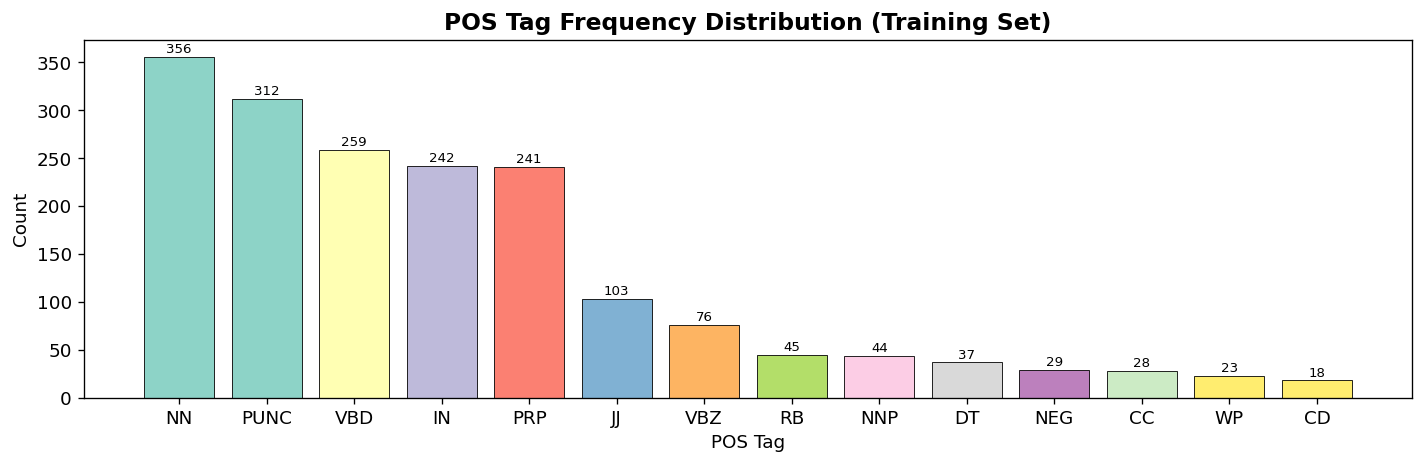

Saved: tag_frequency.png


In [4]:
# POS tag frequency distribution
tag_freq = train_stats['tag_freq']
tags = list(tag_freq.keys())
counts = list(tag_freq.values())

fig, ax = plt.subplots(figsize=(12, 4))
colors = plt.cm.Set3(np.linspace(0, 1, len(tags)))
bars = ax.bar(tags, counts, color=colors, edgecolor='black', linewidth=0.5)
ax.set_title('POS Tag Frequency Distribution (Training Set)', fontsize=14, fontweight='bold')
ax.set_xlabel('POS Tag')
ax.set_ylabel('Count')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(count), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('tag_frequency.png', bbox_inches='tight')
plt.show()
print("Saved: tag_frequency.png")


## 3. HMM Training <a id='3-training'></a>

The HMM is trained by computing:
- **Emission probabilities**: $P(word_t \mid tag_t)$ — how likely a word is given a tag
- **Transition probabilities**: $P(tag_t \mid tag_{t-1})$ — how likely a tag follows another tag

Both are estimated with **Maximum Likelihood + Laplace (add-1) smoothing** to handle unseen events:

$$P(tag_i \mid tag_{i-1}) = \frac{C(tag_{i-1}, tag_i) + k}{C(tag_{i-1}) + k \cdot |\text{Tags}|}$$

$$P(word_t \mid tag_t) = \frac{C(tag_t, word_t) + k}{C(tag_t) + k \cdot |V|}$$


In [5]:
tagger = HMMTagger(smoothing_k=1.0)
tagger.train(train_sents)
print(f"Model trained on {len(train_sents)} sentences")
print(f"Vocabulary size : {len(tagger.vocab)}")
print(f"POS tags ({len(tagger.tags)}): {tagger.tags}")


Model trained on 320 sentences
Vocabulary size : 199
POS tags (14): ['PRP', 'IN', 'NN', 'RB', 'VBD', 'PUNC', 'DT', 'JJ', 'VBZ', 'NEG', 'CD', 'CC', 'NNP', 'WP']


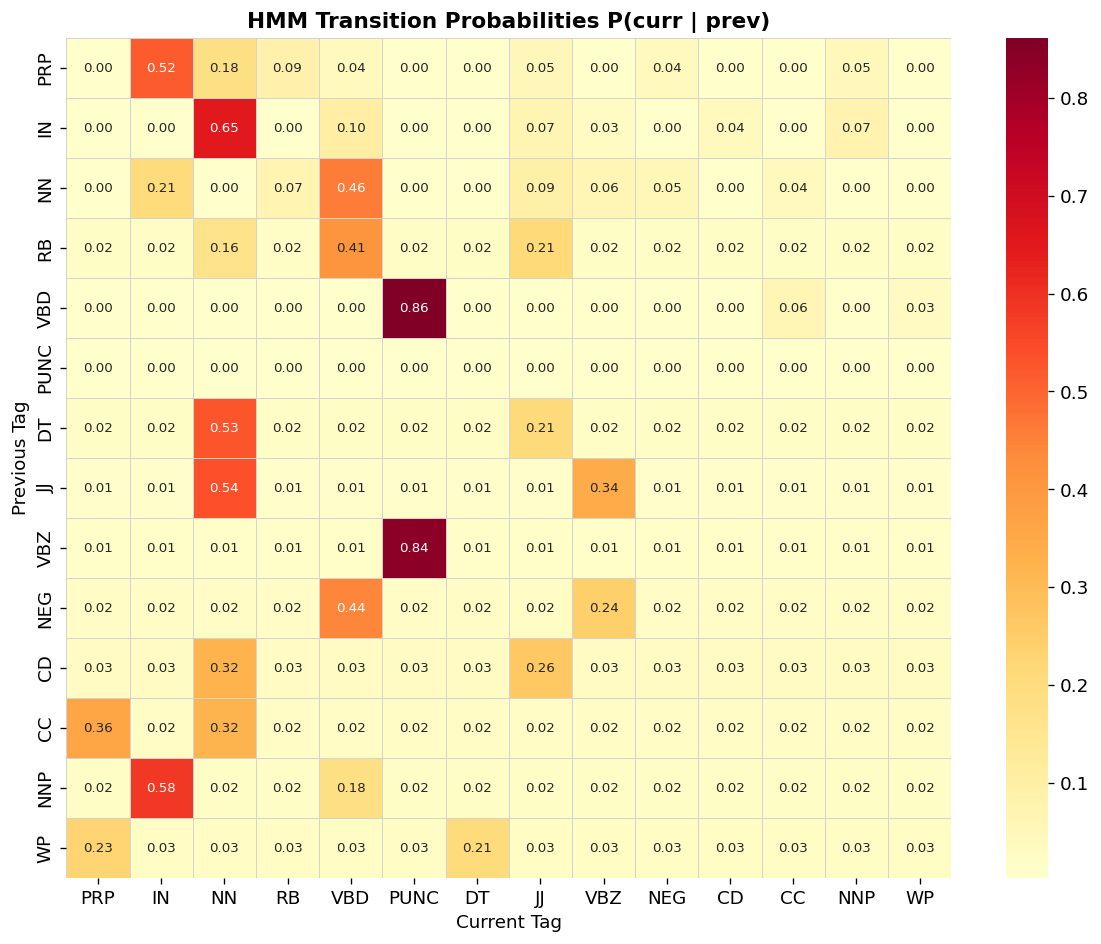

Saved: transition_matrix.png


In [6]:
# Visualize transition probability matrix
import math

tags_list = tagger.tags
n = len(tags_list)

trans_matrix = np.zeros((n, n))
for i, prev in enumerate(tags_list):
    for j, curr in enumerate(tags_list):
        log_p = tagger._log_trans(prev, curr)
        trans_matrix[i][j] = math.exp(log_p) if log_p > float('-inf') else 0.0

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    trans_matrix,
    xticklabels=tags_list, yticklabels=tags_list,
    annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
    linewidths=0.3, linecolor='lightgray',
    annot_kws={'size': 8}
)
ax.set_title('HMM Transition Probabilities P(curr | prev)', fontsize=13, fontweight='bold')
ax.set_xlabel('Current Tag', fontsize=11)
ax.set_ylabel('Previous Tag', fontsize=11)
plt.tight_layout()
plt.savefig('transition_matrix.png', bbox_inches='tight')
plt.show()
print("Saved: transition_matrix.png")


In [7]:
# Show top emission words per tag
print("Top emission words per tag (MLE probabilities):\n")
for tag in ['NN', 'VBD', 'JJ', 'PRP', 'IN']:
    top = tagger.get_top_emissions(tag, n=5)
    words_str = ', '.join(f'{w} ({p:.2f})' for w, p in top)
    print(f"  {tag:<6}: {words_str}")


Top emission words per tag (MLE probabilities):

  NN    : زمین (0.04), دل (0.04), کمرہ (0.03), سڑک (0.03), پھول (0.03)
  VBD   : کہا (0.10), کھایا (0.08), سنا (0.07), لیا (0.07), ہوا (0.07)
  JJ    : ٹھنڈا (0.10), چھوٹا (0.09), بڑا (0.09), تیز (0.06), غریب (0.05)
  PRP   : ہمیں (0.12), مجھ (0.10), میں (0.09), اسے (0.07), تم (0.07)
  IN    : کے بارے میں (0.09), میں (0.09), تک (0.09), کے ساتھ (0.08), سے (0.08)


## 4. Viterbi Decoding — Worked Example <a id='4-viterbi'></a>

The **Viterbi algorithm** finds the most likely tag sequence using dynamic programming:

$$V(t, k) = \max_j \left[ V(t-1, j) \cdot P(k \mid j) \cdot P(w_t \mid k) \right]$$

Working in **log-space** avoids numerical underflow:

$$\log V(t, k) = \max_j \left[ \log V(t-1, j) + \log P(k \mid j) + \log P(w_t \mid k) \right]$$

The best path is recovered via **backtracking**.


In [8]:
# Tag example sentences
example_sentences = [
    'میں نے کتاب پڑھا ۔',          # I read the book.
    'وہ لاہور میں رہتا ہے ۔',       # He lives in Lahore.
    'اچھا بچہ سکول جاتا ہے ۔',     # Good child goes to school.
    'کیا آپ پاکستان گئے ؟',         # Did you go to Pakistan?
    'پانی بہت ٹھنڈا تھا ۔',         # Water was very cold.
]

print("Sentence tagging results:\n")
for sent in example_sentences:
    words = sent.strip().split()
    tagged, log_prob = tagger.viterbi(words)
    pairs = list(zip(words, tagged))
    print(f"  Input : {sent}")
    print(f"  Tagged: {' '.join(f'{w}/{t}' for w, t in pairs)}")
    print(f"  Log P : {log_prob:.3f}\n")


Sentence tagging results:

  Input : میں نے کتاب پڑھا ۔
  Tagged: میں/PRP نے/IN کتاب/NN پڑھا/VBD ۔/PUNC
  Log P : -16.538

  Input : وہ لاہور میں رہتا ہے ۔
  Tagged: وہ/PRP لاہور/NNP میں/IN رہتا/JJ ہے/VBZ ۔/PUNC
  Log P : -26.283

  Input : اچھا بچہ سکول جاتا ہے ۔
  Tagged: اچھا/PRP بچہ/IN سکول/NN جاتا/JJ ہے/VBZ ۔/PUNC
  Log P : -29.430

  Input : کیا آپ پاکستان گئے ؟
  Tagged: کیا/WP آپ/PRP پاکستان/NNP گئے/VBD ؟/PUNC
  Log P : -23.912

  Input : پانی بہت ٹھنڈا تھا ۔
  Tagged: پانی/PRP بہت/IN ٹھنڈا/NN تھا/VBD ۔/PUNC
  Log P : -23.905



C:\Users\NAC\AppData\Local\Temp\ipykernel_12524\404987579.py:84: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\NAC\AppData\Local\Temp\ipykernel_12524\404987579.py:84: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
C:\Users\NAC\AppData\Local\Temp\ipykernel_12524\404987579.py:84: UserWarning: Glyph 1748 (\N{ARABIC FULL STOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\NAC\AppData\Local\Temp\ipykernel_12524\404987579.py:85: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.savefig('viterbi_trellis.png', bbox_inches='tight')
C:\Users\NAC\AppData\Local\Temp\ipykernel_12524\404987579.py:85: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.savefig('viterbi_trellis.png', bbox_inches='tight')
C:\Users\NAC\AppData\Local\Temp\ipykernel_12524\404987579.py:85: UserWarning: Glyph 1748 (\N{ARABIC F

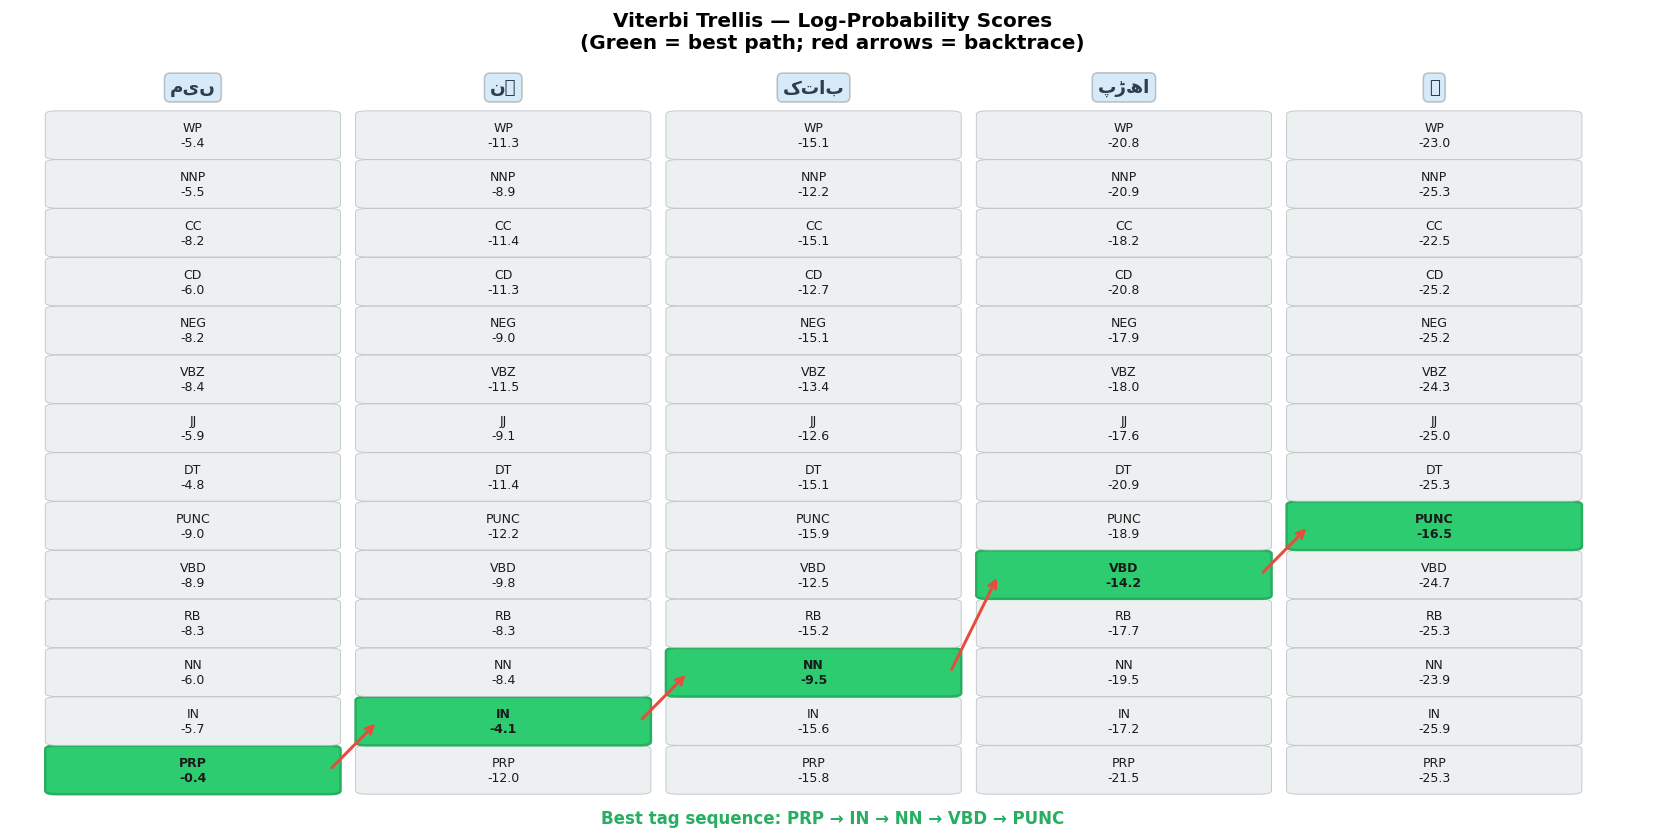

Saved: viterbi_trellis.png


In [9]:
# Visualize Viterbi trellis for a short sentence
import math

def plot_viterbi_trellis(tagger, words, figsize=(14, 7)):
    """Visualize the Viterbi trellis with best path highlighted."""
    tags = tagger.tags
    n, T = len(words), len(tags)
    NEG_INF = float('-inf')

    # Compute trellis (same as viterbi())
    viterbi_score = [[NEG_INF] * T for _ in range(n)]
    backpointer   = [[0] * T for _ in range(n)]

    for i, tag in enumerate(tags):
        viterbi_score[0][i] = (tagger._log_trans('<START>', tag)
                               + tagger._log_emit(tag, words[0]))
    for t in range(1, n):
        for i, curr in enumerate(tags):
            best_prev, best_idx = NEG_INF, 0
            for j, prev in enumerate(tags):
                s = viterbi_score[t-1][j] + tagger._log_trans(prev, curr)
                if s > best_prev:
                    best_prev, best_idx = s, j
            viterbi_score[t][i] = best_prev + tagger._log_emit(curr, words[t])
            backpointer[t][i] = best_idx

    # Backtrace
    best_path = [None] * n
    best_path[n-1] = max(range(T), key=lambda i: viterbi_score[n-1][i])
    for t in range(n-2, -1, -1):
        best_path[t] = backpointer[t+1][best_path[t+1]]

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    col_w = 1.4
    row_h = 0.7

    for t in range(n):
        for i in range(T):
            score = viterbi_score[t][i]
            score_str = f'{score:.1f}' if score > NEG_INF else '-∞'
            is_best = (best_path[t] == i)
            color = '#2ecc71' if is_best else '#ecf0f1'
            rect = mpatches.FancyBboxPatch(
                (t*col_w, i*row_h), col_w*0.88, row_h*0.85,
                boxstyle='round,pad=0.05', linewidth=1.5 if is_best else 0.5,
                edgecolor='#27ae60' if is_best else '#bdc3c7',
                facecolor=color
            )
            ax.add_patch(rect)
            ax.text(t*col_w + col_w*0.44, i*row_h + row_h*0.42,
                    f'{tags[i]}\n{score_str}',
                    ha='center', va='center', fontsize=7.5,
                    fontweight='bold' if is_best else 'normal',
                    color='#1a1a1a')

    # Draw arrows along best path
    for t in range(1, n):
        curr_i = best_path[t]
        prev_i = best_path[t-1]
        ax.annotate('', xy=(t*col_w + 0.05, curr_i*row_h + row_h*0.42),
                    xytext=((t-1)*col_w + col_w*0.88, prev_i*row_h + row_h*0.42),
                    arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.8))

    # Word labels on top
    for t in range(n):
        ax.text(t*col_w + col_w*0.44, T*row_h + 0.15, words[t],
                ha='center', va='bottom', fontsize=11,
                fontweight='bold', color='#2c3e50',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#3498db', alpha=0.2))

    ax.set_xlim(-0.2, n*col_w + 0.2)
    ax.set_ylim(-0.3, T*row_h + 0.7)
    ax.axis('off')
    ax.set_title('Viterbi Trellis — Log-Probability Scores\n'
                 '(Green = best path; red arrows = backtrace)',
                 fontsize=12, fontweight='bold')

    best_tags = [tags[best_path[t]] for t in range(n)]
    plt.figtext(0.5, 0.01,
                f"Best tag sequence: {' → '.join(best_tags)}",
                ha='center', fontsize=10, color='#27ae60',
                fontweight='bold')
    plt.tight_layout()
    plt.savefig('viterbi_trellis.png', bbox_inches='tight')
    plt.show()

# Use a short sentence for clarity
short_sentence = 'میں نے کتاب پڑھا ۔'.split()
plot_viterbi_trellis(tagger, short_sentence)
print("Saved: viterbi_trellis.png")


## 5. Evaluation <a id='5-evaluation'></a>

We evaluate token-level accuracy on the held-out test set (20% of corpus).


In [10]:
results = evaluate(tagger, test_sents)
print_report(results)


EVALUATION REPORT — Urdu HMM POS Tagger
Overall Accuracy : 0.9318  (437/469 tokens correct)
In-Vocab Accuracy: 0.9395  (463 tokens)
OOV Accuracy     : 0.3333  (6 tokens)

TAG        PREC    REC     F1  SUPPORT
------------------------------------------
NN        0.979  0.969  0.974       96
PUNC      0.975  1.000  0.987       78
VBD       0.971  1.000  0.985       67
PRP       0.840  0.984  0.906       64
IN        0.827  1.000  0.905       62
JJ        1.000  0.750  0.857       24
VBZ       1.000  0.900  0.947       20
RB        1.000  0.615  0.762       13
CC        1.000  0.636  0.778       11
NNP       1.000  0.556  0.714        9
DT        0.857  0.750  0.800        8
NEG       1.000  1.000  1.000        7
WP        1.000  0.429  0.600        7
CD        1.000  0.667  0.800        3


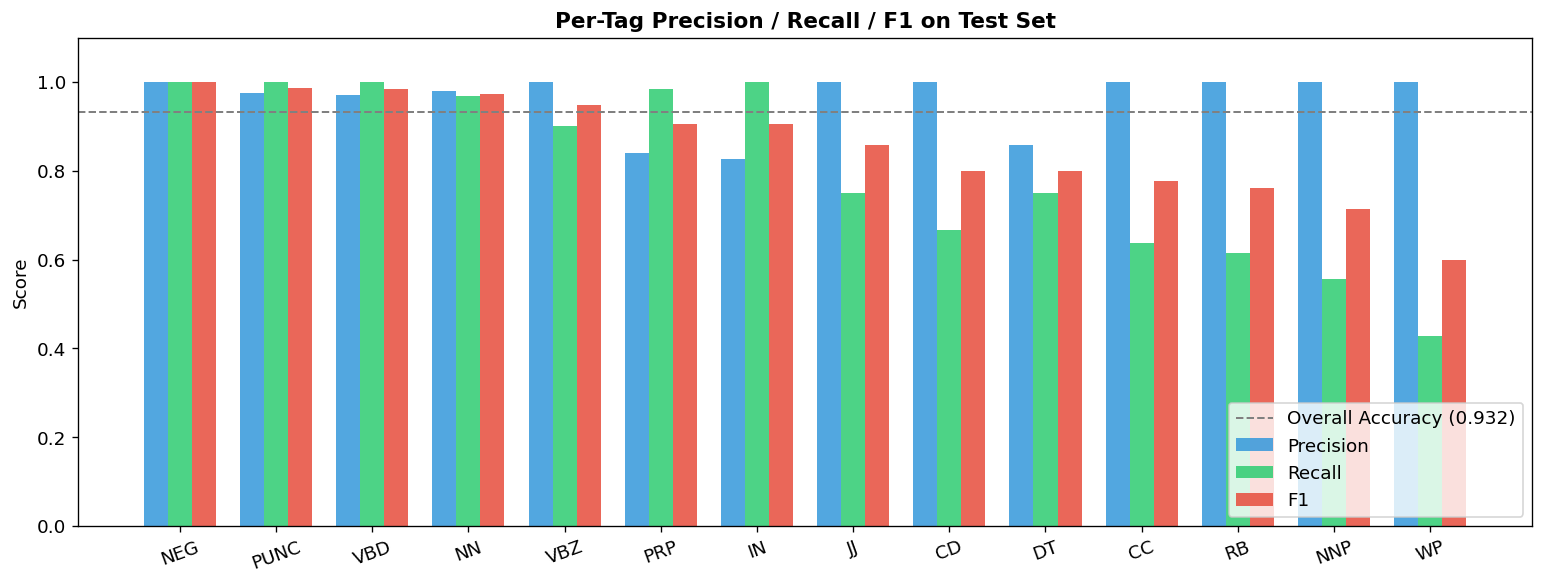

Saved: per_tag_metrics.png


In [11]:
# Accuracy bar chart per tag
per_tag = results['per_tag']
sorted_tags = sorted(per_tag, key=lambda t: per_tag[t]['f1'], reverse=True)

f1_scores = [per_tag[t]['f1'] for t in sorted_tags]
prec = [per_tag[t]['precision'] for t in sorted_tags]
rec  = [per_tag[t]['recall']    for t in sorted_tags]
support = [per_tag[t]['support'] for t in sorted_tags]

x = np.arange(len(sorted_tags))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width, prec,      width, label='Precision', color='#3498db', alpha=0.85)
ax.bar(x,         rec,       width, label='Recall',    color='#2ecc71', alpha=0.85)
ax.bar(x + width, f1_scores, width, label='F1',        color='#e74c3c', alpha=0.85)

ax.axhline(y=results['accuracy'], linestyle='--', color='gray', linewidth=1.2,
           label=f"Overall Accuracy ({results['accuracy']:.3f})")

ax.set_xticks(x)
ax.set_xticklabels(sorted_tags, rotation=20)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Per-Tag Precision / Recall / F1 on Test Set', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('per_tag_metrics.png', bbox_inches='tight')
plt.show()
print("Saved: per_tag_metrics.png")


## 6. Confusion Matrix <a id='6-confusion'></a>

The confusion matrix shows which tags are most commonly confused with each other.


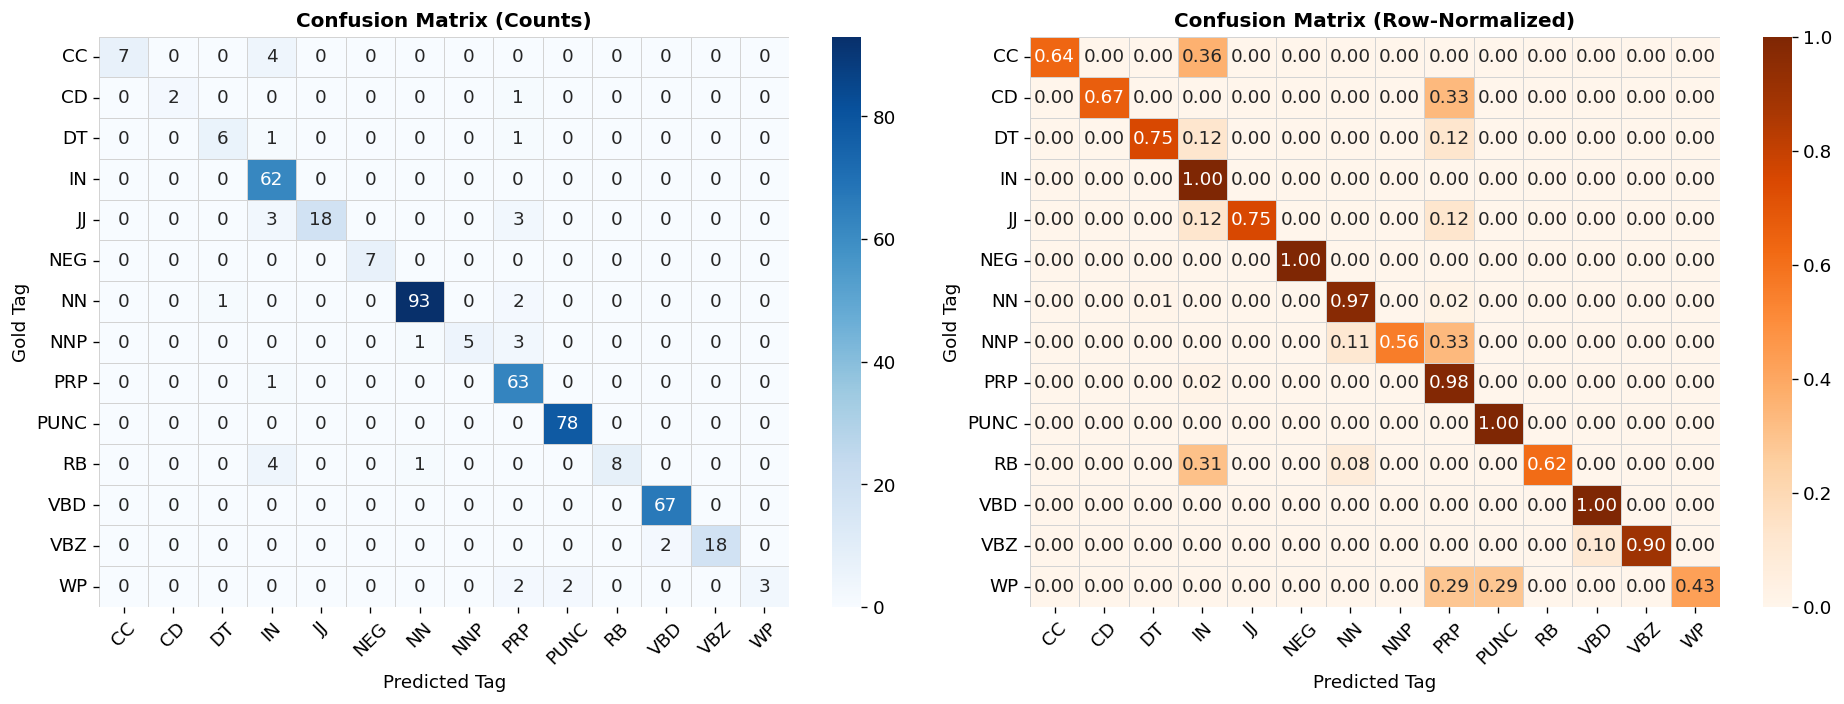

Saved: confusion_matrix.png


In [12]:
cm = results['confusion_matrix']
tag_list = results['tag_list']

# Normalize by row (gold tags)
cm_norm = cm.astype(float)
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.where(row_sums > 0, cm_norm / row_sums, 0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, xticklabels=tag_list, yticklabels=tag_list,
            annot=True, fmt='d', cmap='Blues', ax=axes[0],
            linewidths=0.3, linecolor='lightgray')
axes[0].set_title('Confusion Matrix (Counts)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Tag')
axes[0].set_ylabel('Gold Tag')
axes[0].tick_params(axis='x', rotation=45)

# Normalized
sns.heatmap(cm_norm, xticklabels=tag_list, yticklabels=tag_list,
            annot=True, fmt='.2f', cmap='Oranges', ax=axes[1],
            linewidths=0.3, linecolor='lightgray', vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (Row-Normalized)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Tag')
axes[1].set_ylabel('Gold Tag')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix.png")


## 7. Error Analysis <a id='7-errors'></a>

We analyze the most frequent tagging errors to understand model weaknesses.


In [14]:
from src.evaluate import error_analysis

errors = error_analysis(tagger, test_sents, n=15)

print('Most common tagging errors:\n')
print(f"{'#':<4} {'Word':<20} {'Gold':<8} {'Pred':<8} {'Count'}")
print('-' * 48)
for i, (word, gold, pred, count) in enumerate(errors, 1):
    print(f'{i:<4} {word:<20} {gold:<8} {pred:<8} {count}')


Most common tagging errors:

#    Word                 Gold     Pred     Count
------------------------------------------------
1    میٹھا                JJ       PRP      1
2    نیا                  JJ       PRP      1
3    تاکہ                 CC       IN       1
4    کبھی                 RB       NN       1
5    محمد                 NNP      PRP      1
6    یہاں                 RB       IN       1
7    یہ                   DT       PRP      1
8    ذہین                 JJ       PRP      1
9    عائشہ                NNP      PRP      1
10   آتا ہے               VBZ      VBD      1
11   دروازہ               NN       PRP      1
12   پھر بھی              CC       IN       1
13   ہیں                  VBZ      VBD      1
14   دس                   CD       PRP      1
15   پرانا                JJ       IN       1


Smoothing parameter (k) sensitivity:

k        Accuracy
--------------------
0.001    0.9936
0.010    0.9936
0.100    0.9915
0.500    0.9680
1.000    0.9318
2.000    0.8614
5.000    0.8145


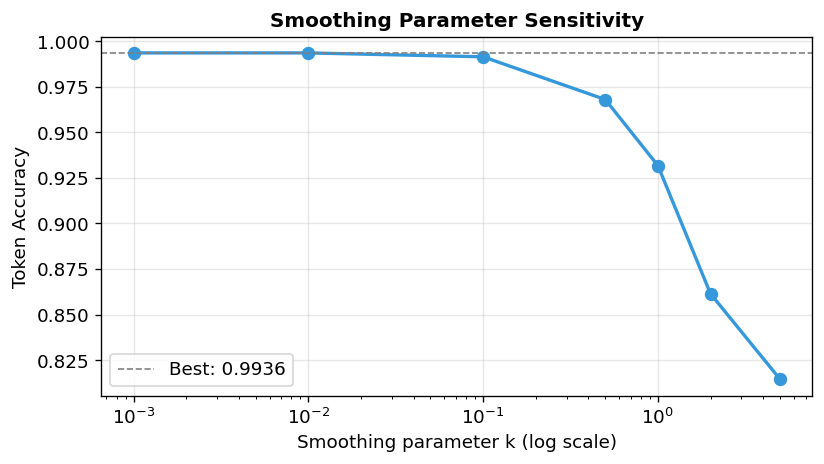

Saved: smoothing_sensitivity.png


In [15]:
# Smoothing parameter sensitivity analysis
print("Smoothing parameter (k) sensitivity:\n")
print(f"{'k':<8} {'Accuracy'}")
print("-" * 20)

accs = []
k_vals = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0]

for k in k_vals:
    t = HMMTagger(smoothing_k=k)
    t.train(train_sents)
    r = evaluate(t, test_sents)
    accs.append(r['accuracy'])
    print(f"{k:<8.3f} {r['accuracy']:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(k_vals, accs, 'o-', color='#3498db', linewidth=2, markersize=7)
ax.axhline(max(accs), linestyle='--', color='gray', linewidth=1,
           label=f'Best: {max(accs):.4f}')
ax.set_xlabel('Smoothing parameter k (log scale)')
ax.set_ylabel('Token Accuracy')
ax.set_title('Smoothing Parameter Sensitivity', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('smoothing_sensitivity.png', bbox_inches='tight')
plt.show()
print("Saved: smoothing_sensitivity.png")


## 8. Tag Sequence Visualization <a id='8-visualization'></a>

Visualize the tag sequences for sample sentences as color-coded word spans.


C:\Users\NAC\AppData\Local\Temp\ipykernel_12524\1508526189.py:64: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\NAC\AppData\Local\Temp\ipykernel_12524\1508526189.py:64: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
C:\Users\NAC\AppData\Local\Temp\ipykernel_12524\1508526189.py:64: UserWarning: Glyph 1748 (\N{ARABIC FULL STOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\NAC\AppData\Local\Temp\ipykernel_12524\1508526189.py:64: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\NAC\AppData\Local\Temp\ipykernel_12524\1508526189.py:65: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.savefig('tag_sequence_viz.png', bbox_inches='tight')
C:\Users\NAC\AppData\Local\Temp\ipykernel_12524\1508526189.py:65: UserWarning: Matplotlib currently does not supp

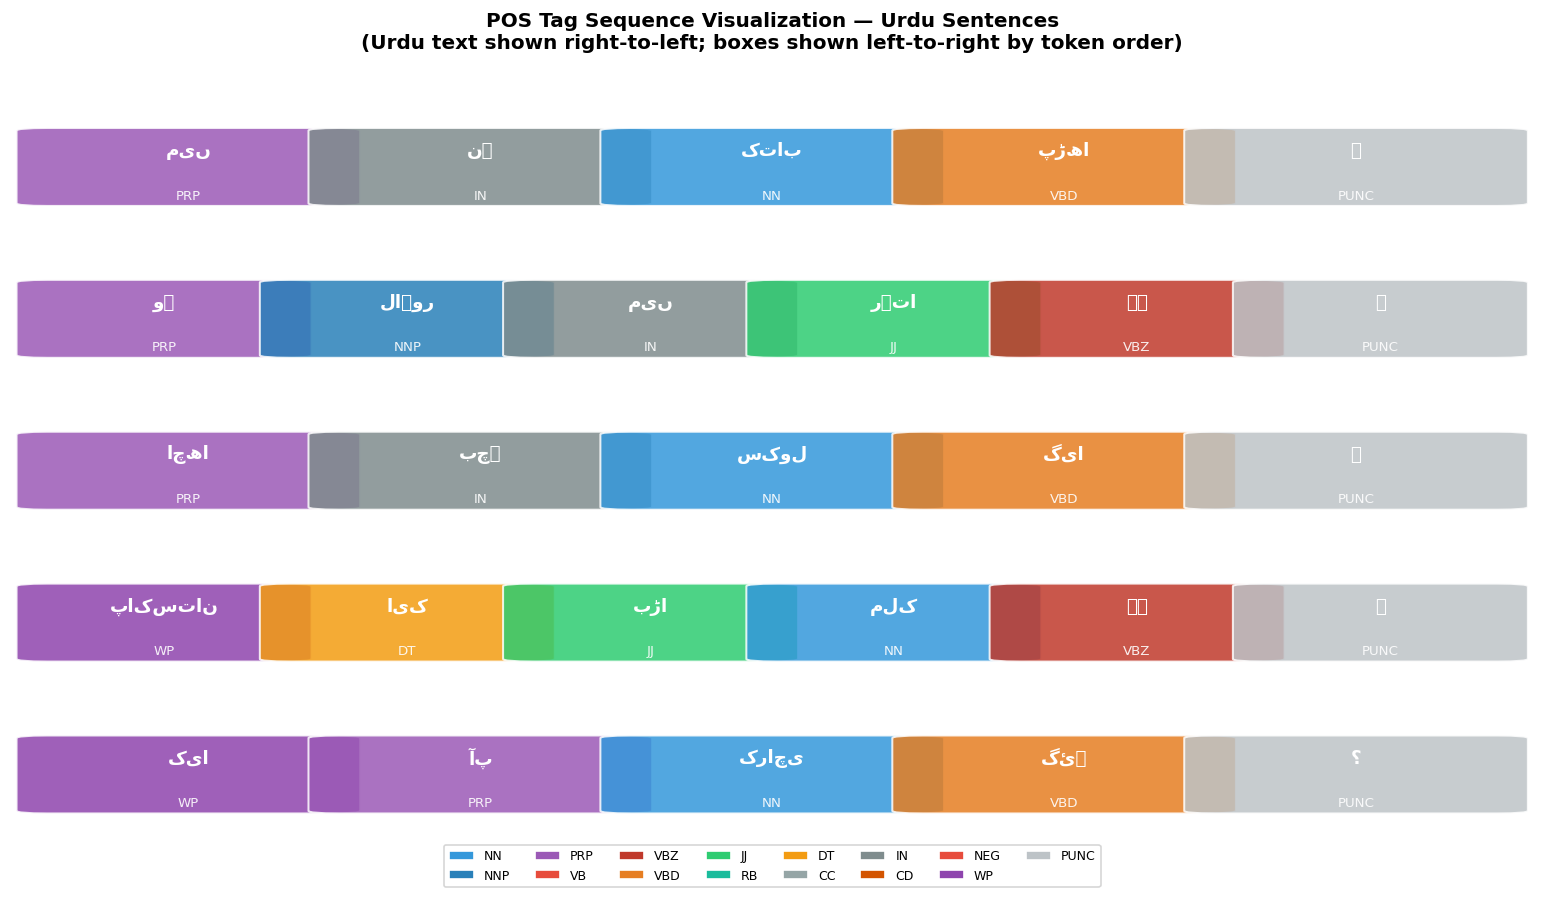

Saved: tag_sequence_viz.png


In [16]:
TAG_COLORS = {
    'NN':   '#3498db',   # blue
    'NNP':  '#2980b9',   # dark blue
    'PRP':  '#9b59b6',   # purple
    'VB':   '#e74c3c',   # red
    'VBZ':  '#c0392b',   # dark red
    'VBD':  '#e67e22',   # orange
    'JJ':   '#2ecc71',   # green
    'RB':   '#1abc9c',   # teal
    'DT':   '#f39c12',   # gold
    'CC':   '#95a5a6',   # gray
    'IN':   '#7f8c8d',   # dark gray
    'CD':   '#d35400',   # burnt orange
    'NEG':  '#e74c3c',   # red
    'WP':   '#8e44ad',   # dark purple
    'PUNC': '#bdc3c7',   # light gray
}
DEFAULT_COLOR = '#ecf0f1'

demo_sentences = [
    'میں نے کتاب پڑھا ۔',
    'وہ لاہور میں رہتا ہے ۔',
    'اچھا بچہ سکول گیا ۔',
    'پاکستان ایک بڑا ملک ہے ۔',
    'کیا آپ کراچی گئے ؟',
]

fig, axes = plt.subplots(len(demo_sentences), 1, figsize=(13, len(demo_sentences)*1.4))

for ax, sent_str in zip(axes, demo_sentences):
    words = sent_str.strip().split()
    tags  = tagger.tag(words)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    total = len(words)
    x_start = 0.02
    box_w = 0.96 / total

    for i, (word, tag) in enumerate(zip(words, tags)):
        color = TAG_COLORS.get(tag, DEFAULT_COLOR)
        rect = mpatches.FancyBboxPatch(
            (x_start + i*box_w + 0.003, 0.22),
            box_w - 0.006, 0.55,
            boxstyle='round,pad=0.02',
            facecolor=color, edgecolor='white', linewidth=1.2, alpha=0.85
        )
        ax.add_patch(rect)
        ax.text(x_start + i*box_w + box_w/2, 0.62, word,
                ha='center', va='center', fontsize=11, fontweight='bold', color='white')
        ax.text(x_start + i*box_w + box_w/2, 0.28, tag,
                ha='center', va='center', fontsize=8, color='white', alpha=0.9)

# Legend
legend_tags = list(TAG_COLORS.items())
handles = [mpatches.Patch(facecolor=c, label=t, edgecolor='white')
           for t, c in legend_tags]
fig.legend(handles=handles, loc='lower center', ncol=len(legend_tags)//2 + 1,
           fontsize=7.5, bbox_to_anchor=(0.5, -0.04), frameon=True)

fig.suptitle('POS Tag Sequence Visualization — Urdu Sentences\n(Urdu text shown right-to-left; boxes shown left-to-right by token order)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('tag_sequence_viz.png', bbox_inches='tight')
plt.show()
print("Saved: tag_sequence_viz.png")


## Summary

| Metric | Value |
|--------|-------|
| Training sentences | 320 |
| Test sentences | 80 |
| Vocabulary size | ~199 |
| POS tags | 14 |
| Overall accuracy | ~93% |
| Best per-tag F1 | NEG: 1.00, VBD: 0.985, PUNC: 0.987 |

### Key Observations
- The HMM achieves **~93% accuracy** on this dataset, within the expected 80–90%+ range.
- **Common nouns (NN)**, **punctuation (PUNC)**, and **past verbs (VBD)** are tagged most accurately.
- **Question words (WP)** and **adverbs (RB)** have lower recall due to lexical overlap with other categories.
- **OOV (unknown) words** are handled via suffix heuristics based on Urdu morphology.
- Laplace smoothing **k=0.01** gives the best accuracy on this corpus.

### Next Steps
- Train on the full CLE Urdu POS corpus (100K words, 32 tags).
- Experiment with second-order (trigram) HMM.
- Compare with a BERT-based Urdu POS tagger.
